In [366]:
import pandas as pd
import numpy as np
import geopandas as gpd
import fiona
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.compose import TransformedTargetRegressor

In [367]:
# Read in the raw resale dataset
df = pd.read_csv("Resale flat prices based on registration date from Jan-2017 onwards.csv")
print(df.shape)
print(df.dtypes)
df.head()

(224766, 11)
month                   object
town                    object
flat_type               object
block                   object
street_name             object
storey_range            object
floor_area_sqm         float64
flat_model              object
lease_commence_date      int64
remaining_lease         object
resale_price           float64
dtype: object


,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
0,2017-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,232000.0
1,2017-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,250000.0
2,2017-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,262000.0
3,2017-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62 years 01 month,265000.0
4,2017-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,265000.0


In [368]:
# Read in RPI dataset
rpi_df = pd.read_csv("HDBResalePriceIndex1Q2009100Quarterly.csv")
rpi_df.head()

,quarter,index
0,1990-Q1,24.3
1,1990-Q2,24.4
2,1990-Q3,25.0
3,1990-Q4,24.7
4,1991-Q1,24.9


In [369]:
# Convert the resale dataset month column into a quarter column to match the RPI dataset

# Parse month column into datetime format
df["month"] = pd.to_datetime(df["month"])

# Convert month into quarter format such as 2024-Q1
df["quarter"] = df["month"].dt.to_period('Q').astype(str)

# Replace Q with -Q for consistent formatting to match RPI
df["quarter"] = df["quarter"].astype(str).str.replace('Q', '-Q')
df["quarter"]

0         2017-Q1
1         2017-Q1
2         2017-Q1
3         2017-Q1
4         2017-Q1
           ...   
224761    2026-Q1
224762    2026-Q1
224763    2026-Q1
224764    2026-Q1
224765    2026-Q1
Name: quarter, Length: 224766, dtype: object

In [370]:
# Merge resale data with the RPI data using the quarter column
df = df.merge(rpi_df, on='quarter', how='left')

# Rename the merged RPI column for clarity
df.rename(columns={'index': 'RPI'}, inplace=True)
df.head()

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price,quarter,RPI
0,2017-01-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,232000.0,2017-Q1,133.9
1,2017-01-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,250000.0,2017-Q1,133.9
2,2017-01-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,262000.0,2017-Q1,133.9
3,2017-01-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62 years 01 month,265000.0,2017-Q1,133.9
4,2017-01-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,265000.0,2017-Q1,133.9


# Geospatial Data Preparation

In [371]:
# Read in the dataset with coordinates extracted using OneMap API
df_geo = pd.read_csv("location_with_latlong.csv")

#Split the lat and long into different columns
df_geo[["lat", "long"]] = df_geo["Lat Long"].str.split(",", expand=True)
df.head()

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price,quarter,RPI
0,2017-01-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,232000.0,2017-Q1,133.9
1,2017-01-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,250000.0,2017-Q1,133.9
2,2017-01-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,262000.0,2017-Q1,133.9
3,2017-01-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62 years 01 month,265000.0,2017-Q1,133.9
4,2017-01-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,265000.0,2017-Q1,133.9


## Geospatial for Resale Price Dataset

In [372]:
# Create GeoDataFrame by converting latitude and longitude into point geometry
loc = gpd.GeoDataFrame(
    df_geo,
    geometry=gpd.points_from_xy(df_geo["long"], df_geo["lat"]),
    crs="EPSG:4326"
)

# Convert coordinates to meters for distance calculations
loc_m = loc.to_crs(epsg=3414)

# Extract x and y meter coordinates from geometry into separate columns
loc_m["x_m"] = loc_m.geometry.x
loc_m["y_m"] = loc_m.geometry.y

loc_m.head()

,block,street_name,Location,Lat Long,lat,long,geometry,x_m,y_m
0,406,ANG MO KIO AVE 10,406 ANG MO KIO AVE 10,"1.36200453938712, 103.853879910407",1.36200453938712,103.853879910407,POINT (30288.235 38229.067),30288.234663,38229.067463
1,108,ANG MO KIO AVE 4,108 ANG MO KIO AVE 4,"1.37096635222625, 103.838201940326",1.37096635222625,103.838201940326,POINT (28543.459 39220.010),28543.458747,39220.009892
2,602,ANG MO KIO AVE 5,602 ANG MO KIO AVE 5,"1.38070883044887, 103.835368226602",1.38070883044887,103.835368226602,POINT (28228.100 40297.283),28228.099954,40297.283149
3,465,ANG MO KIO AVE 10,465 ANG MO KIO AVE 10,"1.3662010408294, 103.857200967235",1.3662010408294,103.857200967235,POINT (30657.825 38693.099),30657.824693,38693.098657
4,601,ANG MO KIO AVE 5,601 ANG MO KIO AVE 5,"1.38104134784496, 103.835131744823",1.38104134784496,103.835131744823,POINT (28201.782 40334.051),28201.782487,40334.051212


## Geospatial for MRT Station Dataset

In [373]:
# Read in MRT station dataset which already contains point geometry
mrt = gpd.read_file("LTA MRT Station Exit (GEOJSON).geojson")

# Convert coordinates to meters for distance calculations
mrt_m = mrt.to_crs(epsg=3414)

# Extract x and y meter coordinates from geometry into separate columns
mrt_m["x_m"] = mrt_m.geometry.x
mrt_m["y_m"] = mrt_m.geometry.y

mrt_m.head()

,OBJECTID,STATION_NA,EXIT_CODE,INC_CRC,FMEL_UPD_D,geometry,x_m,y_m
0,17885,BRIGHT HILL MRT STATION,Exit 1,CFB9350F44E8991A,20251202172807,POINT (28035.260 38453.817),28035.2600,38453.8170
1,17886,BRIGHT HILL MRT STATION,Exit 2,F273E9D550B06062,20251202172807,POINT (28021.373 38370.397),28021.3732,38370.3971
2,17887,BRIGHT HILL MRT STATION,Exit 4,BC4A442B12F99E85,20251202172807,POINT (27848.120 38357.260),27848.1195,38357.2602
3,17888,BRIGHT HILL MRT STATION,Exit 3,2A45076ED986B275,20251202172807,POINT (27895.070 38248.880),27895.0699,38248.8800
4,17889,UPPER THOMSON MRT STATION,Exit 2,3EA737829473A972,20251202172807,POINT (27834.673 37535.978),27834.6731,37535.9782


In [374]:
# Find the nearest MRT station for each flat and compute the distance in meters
nearest_mrt = gpd.sjoin_nearest(
    loc_m,
    mrt_m[["STATION_NA", "EXIT_CODE", "geometry"]],
    how="left",
    distance_col="dist_to_mrt_m"
)

nearest_mrt[["Location", "STATION_NA", "EXIT_CODE", "dist_to_mrt_m"]].sort_values("dist_to_mrt_m", ascending=True)

,Location,STATION_NA,EXIT_CODE,dist_to_mrt_m
6112,620 BEDOK RESERVOIR RD,BEDOK NORTH MRT STATION,Exit C,14.632192
67938,620 BEDOK RESERVOIR RD,BEDOK NORTH MRT STATION,Exit C,14.632192
197975,620 BEDOK RESERVOIR RD,BEDOK NORTH MRT STATION,Exit C,14.632192
30334,620 BEDOK RESERVOIR RD,BEDOK NORTH MRT STATION,Exit C,14.632192
198311,620 BEDOK RESERVOIR RD,BEDOK NORTH MRT STATION,Exit C,14.632192
...,...,...,...,...
209381,4 CHANGI VILLAGE RD,CHANGI AIRPORT MRT STATION,Exit B,3524.753835
105247,4 CHANGI VILLAGE RD,CHANGI AIRPORT MRT STATION,Exit B,3524.753835
55490,4 CHANGI VILLAGE RD,CHANGI AIRPORT MRT STATION,Exit B,3524.753835
5159,4 CHANGI VILLAGE RD,CHANGI AIRPORT MRT STATION,Exit B,3524.753835


## Geospatial for Shopping Mall Dataset

In [375]:
# Read in cleaned mall dataset with lat and long coordinates
df_mall = pd.read_csv("mall_cleaned.csv")

In [376]:
# Create GeoDataFrame by converting latitude and longitude into point geometry
mall = gpd.GeoDataFrame(
    df_mall,
    geometry=gpd.points_from_xy(df_mall["long"], df_mall["lat"]),
    crs="EPSG:4326"
)

# Convert coordinates to meters for distance calculations
mall_m = mall.to_crs(epsg=3414)

# Extract x and y meter coordinates from geometry into separate columns
mall_m["x_m"] = mall_m.geometry.x
mall_m["y_m"] = mall_m.geometry.y

mall_m.head()

,name,category,lat,long,geometry,x_m,y_m
0,The Star Vista,mall,1.308002,103.788382,POINT (22999.033 32257.723),22999.032742,32257.722988
1,Bencoolen Underground Mall,mall,1.299224,103.850755,POINT (29940.529 31287.081),29940.528978,31287.080954
2,Katong V,mall,1.303133,103.903231,POINT (35780.640 31719.497),35780.639911,31719.496666
3,The Poiz Centre,mall,1.331436,103.868571,POINT (31923.218 34848.973),31923.218248,34848.972883
4,Clarke Quay Central,mall,1.288999,103.846180,POINT (29431.322 30156.516),29431.322422,30156.516460


In [377]:
# Find the nearest mall for each flat and compute the distance in meters
nearest_mall = gpd.sjoin_nearest(
    loc_m,
    mall_m[["name", "geometry"]],
    how="left",
    distance_col="dist_to_mall_m"
)

nearest_mall[["Location", "name", "dist_to_mall_m"]].sort_values("dist_to_mall_m", ascending=True)

,Location,name,dist_to_mall_m
207839,221 BOON LAY PL,Boon Lay Shopping Centre,5.936268
128384,221 BOON LAY PL,Boon Lay Shopping Centre,5.936268
3109,221 BOON LAY PL,Boon Lay Shopping Centre,5.936268
99919,221 BOON LAY PL,Boon Lay Shopping Centre,5.936268
74094,221 BOON LAY PL,Boon Lay Shopping Centre,5.936268
...,...,...,...
83967,4 CHANGI VILLAGE RD,Changi Airport Terminal 1,2945.569909
105247,4 CHANGI VILLAGE RD,Changi Airport Terminal 1,2945.569909
5159,4 CHANGI VILLAGE RD,Changi Airport Terminal 1,2945.569909
183880,4 CHANGI VILLAGE RD,Changi Airport Terminal 1,2945.569909


## Geospatial for School Dataset

In [378]:
# Read in cleaned school dataset with lat long coordinates
df_school = pd.read_csv("school_cleaned.csv")
df_school[["lat", "long"]] = df_school["Lat Long"].str.split(",", expand=True)

In [379]:
# Create GeoDataFrame by converting latitude and longitude into point geometry
school = gpd.GeoDataFrame(
    df_school,
    geometry=gpd.points_from_xy(df_school["long"], df_school["lat"]),
    crs="EPSG:4326"
)

# Convert coordinates to meters for distance calculations
school_m = school.to_crs(epsg=3414)

# Extract x and y meter coordinates from geometry into separate columns
school_m["x_m"] = school_m.geometry.x
school_m["y_m"] = school_m.geometry.y

school_m.head()

,school_name,address,Lat Long,lat,long,geometry,x_m,y_m
0,ADMIRALTY PRIMARY SCHOOL,11 WOODLANDS CIRCLE,"1.4426347903311, 103.800040119743",1.4426347903311,103.800040119743,POINT (24296.625 47144.770),24296.625086,47144.770059
1,ADMIRALTY SECONDARY SCHOOL,31 WOODLANDS CRESCENT,"1.44589068910993, 103.802398196596",1.44589068910993,103.802398196596,POINT (24559.047 47504.787),24559.047294,47504.787355
2,AHMAD IBRAHIM PRIMARY SCHOOL,10 YISHUN STREET 11,"1.43315271543517, 103.832942401086",1.43315271543517,103.832942401086,POINT (27958.137 46096.263),27958.137143,46096.262768
3,AHMAD IBRAHIM SECONDARY SCHOOL,751 YISHUN AVENUE 7,"1.43605975368804, 103.829718690077",1.43605975368804,103.829718690077,POINT (27599.387 46417.709),27599.387289,46417.708755
4,AI TONG SCHOOL,100 Bright Hill Drive,"1.3605834338904, 103.833020333986",1.3605834338904,103.833020333986,POINT (27966.809 38071.919),27966.808830,38071.919118


In [380]:
# Find the nearest school for each flat and compute the distance in meters
nearest_school = gpd.sjoin_nearest(
    loc_m,
    school_m[["school_name", "geometry"]],
    how="left",
    distance_col="dist_to_school_m"
)

nearest_school[["Location", "school_name", "dist_to_school_m"]].sort_values("dist_to_school_m", ascending=True)

,Location,school_name,dist_to_school_m
32463,749 WOODLANDS CIRCLE,EVERGREEN PRIMARY SCHOOL,43.540042
18765,749 WOODLANDS CIRCLE,EVERGREEN PRIMARY SCHOOL,43.540042
60190,749 WOODLANDS CIRCLE,EVERGREEN PRIMARY SCHOOL,43.540042
40424,749 WOODLANDS CIRCLE,EVERGREEN PRIMARY SCHOOL,43.540042
14951,749 WOODLANDS CIRCLE,EVERGREEN PRIMARY SCHOOL,43.540042
...,...,...,...
223370,4 CHANGI VILLAGE RD,PASIR RIS PRIMARY SCHOOL,3293.326522
130589,4 CHANGI VILLAGE RD,PASIR RIS PRIMARY SCHOOL,3293.326522
105247,4 CHANGI VILLAGE RD,PASIR RIS PRIMARY SCHOOL,3293.326522
183880,4 CHANGI VILLAGE RD,PASIR RIS PRIMARY SCHOOL,3293.326522


## Geospatial for Hawker Centre Dataset

In [381]:
# Read in hawker dataset which already contains point geometry
hawker = gpd.read_file("HawkerCentresGEOJSON.geojson")

# Convert coordinates to meters for distance calculations
hawker_m = hawker.to_crs(epsg=3414)

# Extract x and y meter coordinates from geometry into separate columns
hawker_m["x_m"] = hawker_m.geometry.x
hawker_m["y_m"] = hawker_m.geometry.y

hawker_m.head()

,OBJECTID,LANDXADDRESSPOINT,LANDYADDRESSPOINT,ADDRESSBUILDINGNAME,ADDRESSPOSTALCODE,ADDRESSSTREETNAME,DESCRIPTION,NAME,PHOTOURL,ADDRESSBLOCKHOUSENUMBER,...,INFO_ON_CO_LOCATORS,ADDRESS_MYENV,EST_ORIGINAL_COMPLETION_DATE,HUP_COMPLETION_DATE,NUMBER_OF_COOKED_FOOD_STALLS,INC_CRC,FMEL_UPD_D,geometry,x_m,y_m
0,119091,29433.149958,29089.977309,MND COMPLEX (ANNEXE B),069111,MAXWELL ROAD,HUP Standard Upgrading,Amoy Street Food Centre (Telok Ayer Food Centre),http://www.nea.gov.sg/images/default-source/Ha...,7,...,None,"National Development Building, Annex B, Telok ...",1983,17/02/2003,134,1166A0D172748172,20250807100106,POINT (29480.260 29076.412),29480.2600,29076.4117
1,119092,24814.315270,31095.008246,SKYRESIDENCE @ DAWSON,142038,Margaret Drive,New Replacement Centre,Margaret Drive Hawker Centre,None,38A,...,hawker centre/branch office,None,30/3/2022,None,38,939D0746E9A0AAE2,20250807100106,POINT (24814.315 31095.008),24814.3153,31095.0082
2,119093,36371.367601,44035.866513,PUNGGOL COAST MALL,829911,Punggol Way,New Centre,Punggol Coast Hawker Centre,None,84,...,hawker centre/community club/bus interchange/c...,None,21/8/2024,None,40,6C6754A6627194EC,20250807100106,POINT (36371.368 44035.867),36371.3676,44035.8665
3,119094,25229.980557,28415.041953,TELOK BLANGAH BEACON,103078,Telok Blangah Drive,New Replacement Centre,Telok Blangah Hawker Centre & Market,None,78C,...,hawker centre/market/flats,None,2027,None,40,4D0564D8E8B5675A,20250807100106,POINT (25229.981 28415.042),25229.9806,28415.0420
4,119095,21621.868911,35735.435084,BUKIT TIMAH MARKET,588215,Upper Bukit Timah Road,New Replacement Centre,Bukit Timah Market,None,51,...,hawker centre/market/community club/indoor spo...,"51, Upper Bukit Timah Road, Singapore 588215",2029,None,82,AF868AA387991B66,20250807100106,POINT (21657.827 35711.565),21657.8268,35711.5653


In [382]:
# Find the nearest hawker for each flat and compute the distance in meters
nearest_hawker = gpd.sjoin_nearest(
    loc_m,
    hawker_m[["NAME", "ADDRESSBUILDINGNAME", "ADDRESSSTREETNAME", "geometry"]],
    how="left",
    distance_col="dist_to_hawker_m"
)

nearest_hawker[["Location", "NAME", "ADDRESSBUILDINGNAME", "dist_to_hawker_m"]].sort_values("dist_to_hawker_m", ascending=True)

,Location,NAME,ADDRESSBUILDINGNAME,dist_to_hawker_m
202634,32 NEW MKT RD,New Market Road Blk 32 (People's Park Food Cen...,None,0.000025
28704,32 NEW MKT RD,New Market Road Blk 32 (People's Park Food Cen...,None,0.000025
88170,32 NEW MKT RD,New Market Road Blk 32 (People's Park Food Cen...,None,0.000025
175725,32 NEW MKT RD,New Market Road Blk 32 (People's Park Food Cen...,None,0.000025
149332,32 NEW MKT RD,New Market Road Blk 32 (People's Park Food Cen...,None,0.000025
...,...,...,...,...
150310,463 CHOA CHU KANG AVE 4,Yew Tee Hawker Centre,Heart of Yew Tee,2500.136583
15645,463 CHOA CHU KANG AVE 4,Yew Tee Hawker Centre,Heart of Yew Tee,2500.136583
11987,463 CHOA CHU KANG AVE 4,Yew Tee Hawker Centre,Heart of Yew Tee,2500.136583
10231,463 CHOA CHU KANG AVE 4,Yew Tee Hawker Centre,Heart of Yew Tee,2500.136583


## Geospatial for SPF Dataset

In [383]:
# Read SPF dataset which already contains point geometry
spf = gpd.read_file("SingaporePoliceForceEstablishments.geojson")

# Remove duplicates rows
spf_clean = spf.sort_values(["DEPARTMENT","TYPE","STREET_NAME"]).drop_duplicates(subset="geometry")

# Convert coordinates to meters for distance calculations
spf_m = spf_clean.to_crs(epsg=3414)

# Extract x and y meter coordinates from geometry into separate columns
spf_m["x_m"] = spf_m.geometry.x
spf_m["y_m"] = spf_m.geometry.y

spf_m.head()

,OBJECTID_1,DEPARTMENT,ALT_TELEPHONE_LINE,STREET_NAME,BUILDING_NAME,TYPE,TELEPHONE,UNIT,OPERATING_HOURS,FAX,HSE_BLK_NO,POSTAL_CODE,INC_CRC,FMEL_UPD_D,geometry,x_m,y_m
51,6820,Administration & Finance Department,None,Irrawaddy Road,New Phoenix Park,Police Headquarters,6353 0000,None,Not open to the public,-,28,329560,80BD314597DDD674,20181122165117,POINT (29297.297 34055.886),29297.2965,34055.8863
48,6817,Airport Police Division,None,Airport Boulevard Road,None,Other Police Units,6546 0000,None,Not open to the public,6545 2213,35,819645,F065965138E61D9B,20181122165117,POINT (44401.494 36151.482),44401.4938,36151.4820
76,6845,Aljunied Neighbourhood Police Post (Self-Help ...,None,Joo Seng Road,None,Tanglin Police Divisional (ECHO),None,#01-69,24 Hrs (Automated),None,13,360013,E7E268549815ACDD,20231220121312,POINT (33117.372 35328.490),33117.3718,35328.4901
112,6777,Anchorvale Neighbourhood Police Post (Self-Hel...,None,Anchorvale Crescent,None,Ang Mo Kio Police Division (FOXTROT),None,None,24 Hrs (Automated),None,338D,544338,49AC6DA6E00C5EAC,20251015175424,POINT (34164.770 42397.309),34164.7701,42397.3086
42,6811,Ang Mo Kio North Neighbourhood Police Centre,None,Ang Mo Kio Avenue 9,None,Ang Mo Kio Police Division (FOXTROT),1800 484 9999,None,24 Hrs,6218 1399,51,569784,C4C3D5B340084A21,20181122165117,POINT (29306.848 40764.231),29306.8481,40764.2314


In [384]:
# Find the nearest SPF establishment for each flat and compute the distance in meters
nearest_spf = gpd.sjoin_nearest(
    loc_m,
    spf_m[["DEPARTMENT", "TYPE", "STREET_NAME", "geometry"]],
    how="left",
    distance_col="dist_to_spf_m"
)

nearest_spf[["Location", "DEPARTMENT", "TYPE", "STREET_NAME", "dist_to_spf_m"]].sort_values("dist_to_spf_m", ascending=True)

,Location,DEPARTMENT,TYPE,STREET_NAME,dist_to_spf_m
63284,29 JLN BAHAGIA,Whampoa Neighbourhood Police Post (Self-Help K...,Tanglin Police Divisional (ECHO),Jalan Bahagia,0.000011
59366,29 JLN BAHAGIA,Whampoa Neighbourhood Police Post (Self-Help K...,Tanglin Police Divisional (ECHO),Jalan Bahagia,0.000011
16072,29 JLN BAHAGIA,Whampoa Neighbourhood Police Post (Self-Help K...,Tanglin Police Divisional (ECHO),Jalan Bahagia,0.000011
155336,29 JLN BAHAGIA,Whampoa Neighbourhood Police Post (Self-Help K...,Tanglin Police Divisional (ECHO),Jalan Bahagia,0.000011
63305,29 JLN BAHAGIA,Whampoa Neighbourhood Police Post (Self-Help K...,Tanglin Police Divisional (ECHO),Jalan Bahagia,0.000011
...,...,...,...,...,...
5159,4 CHANGI VILLAGE RD,Pasir Ris Neighbourhood Police Centre,Bedok Police Division (GOLF),Pasir Ris Drive 4,3877.808581
183880,4 CHANGI VILLAGE RD,Pasir Ris Neighbourhood Police Centre,Bedok Police Division (GOLF),Pasir Ris Drive 4,3877.808581
130589,4 CHANGI VILLAGE RD,Pasir Ris Neighbourhood Police Centre,Bedok Police Division (GOLF),Pasir Ris Drive 4,3877.808581
209381,4 CHANGI VILLAGE RD,Pasir Ris Neighbourhood Police Centre,Bedok Police Division (GOLF),Pasir Ris Drive 4,3877.808581


In [385]:
# Combine all nearest amenity distance columns into one dataframe
loc_all = loc_m.copy()

# List each nearest amenity dataframe and the distance column to add
cols_to_add = [
    (nearest_mrt, ["dist_to_mrt_m"]),
    (nearest_mall, ["dist_to_mall_m"]),
    (nearest_school, ["dist_to_school_m"]),
    (nearest_hawker, ["dist_to_hawker_m"]),
    (nearest_spf,    ["dist_to_spf_m"]),
]

# Join each nearest amenity distance column into the main location dataframe
for df_nearest, cols in cols_to_add:
    loc_all = loc_all.join(df_nearest[cols])

In [386]:
# Check and make sure no null value
loc_all.isna().sum()

block               0
street_name         0
Location            0
Lat Long            0
lat                 0
long                0
geometry            0
x_m                 0
y_m                 0
dist_to_mrt_m       0
dist_to_mall_m      0
dist_to_school_m    0
dist_to_hawker_m    0
dist_to_spf_m       0
dtype: int64

### COMBINE DF

In [387]:
# Combine main resale dataset with location distance dataset
df = df.join(loc_all[["dist_to_mrt_m", "dist_to_mall_m", "dist_to_school_m", "dist_to_hawker_m", "dist_to_spf_m"]])
df

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price,quarter,RPI,dist_to_mrt_m,dist_to_mall_m,dist_to_school_m,dist_to_hawker_m,dist_to_spf_m
0,2017-01-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,232000.0,2017-Q1,133.9,934.249034,1027.883036,227.902618,172.410689,700.649811
1,2017-01-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,250000.0,2017-Q1,133.9,160.176577,869.965513,241.572335,408.448982,136.555811
2,2017-01-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,262000.0,2017-Q1,133.9,390.204129,1526.601124,775.445626,586.167266,1108.541396
3,2017-01-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62 years 01 month,265000.0,2017-Q1,133.9,885.083182,892.872255,518.558573,244.836572,741.171455
4,2017-01-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,265000.0,2017-Q1,133.9,376.976459,1570.330140,781.266765,611.702356,1149.265548
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
224761,2026-01-01,YISHUN,EXECUTIVE,325,YISHUN CTRL,04 TO 06,146.0,Maisonette,1988,61 years 11 months,920000.0,2026-Q1,NaN,725.118656,430.940678,342.194942,552.047456,207.744596
224762,2026-01-01,YISHUN,EXECUTIVE,360,YISHUN RING RD,07 TO 09,142.0,Apartment,1988,61 years 07 months,865888.0,2026-Q1,NaN,1137.707795,741.408963,181.746058,321.472237,627.043848
224763,2026-01-01,YISHUN,EXECUTIVE,643,YISHUN ST 61,10 TO 12,142.0,Apartment,1987,60 years 09 months,825000.0,2026-Q1,NaN,604.959744,545.497230,233.272843,908.298823,535.649392
224764,2026-01-01,YISHUN,EXECUTIVE,643,YISHUN ST 61,04 TO 06,146.0,Maisonette,1987,60 years 08 months,788000.0,2026-Q1,NaN,604.959744,545.497230,233.272843,908.298823,535.649392


In [388]:
# Sort the dataset by month, then by town
df = df.sort_values(["month", "town"])

In [389]:
# Check for missing values
df.isna().sum()

month                     0
town                      0
flat_type                 0
block                     0
street_name               0
storey_range              0
floor_area_sqm            0
flat_model                0
lease_commence_date       0
remaining_lease           0
resale_price              0
quarter                   0
RPI                    2689
dist_to_mrt_m             0
dist_to_mall_m            0
dist_to_school_m          0
dist_to_hawker_m          0
dist_to_spf_m             0
dtype: int64

In [390]:
# Since 2026 Q1 RPI has not been release, forward fill missing RPI values using the previous quarter's RPI
df["RPI"] = df["RPI"].ffill()

In [391]:
df.columns

Index(['month', 'town', 'flat_type', 'block', 'street_name', 'storey_range',
       'floor_area_sqm', 'flat_model', 'lease_commence_date',
       'remaining_lease', 'resale_price', 'quarter', 'RPI', 'dist_to_mrt_m',
       'dist_to_mall_m', 'dist_to_school_m', 'dist_to_hawker_m',
       'dist_to_spf_m'],
      dtype='object')

## Duplicate Checks

In [392]:
# Check the number of fully duplicated rows, e.g. 2 identical rows
full_dups = df.duplicated().sum()
print("Full row duplicates:", full_dups)

# Check duplicates based on key transaction fields
# remaining_lease has been excluded as it doesn't make sense to have the same transaction month and year but different remaining lease for same HDB building
key_cols = [
    "month", "town", "flat_type", "block", "street_name",
    "storey_range", "floor_area_sqm", "flat_model", "lease_commence_date", "resale_price", 
]

key_dups = df.duplicated(subset=key_cols, keep="first").sum()
print("Duplicates by key columns:", key_dups)

Full row duplicates: 311
Duplicates by key columns: 395


In [393]:
# Show fully duplicated rows, including all repeated occurrences
full_dup_rows = df[df.duplicated(keep=False)]

# Sort duplicated rows across all columns for easier inspection
full_dup_rows.sort_values(df.columns.tolist()).head()

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price,quarter,RPI,dist_to_mrt_m,dist_to_mall_m,dist_to_school_m,dist_to_hawker_m,dist_to_spf_m
224,2017-01-01,BUKIT MERAH,4 ROOM,106,HENDERSON CRES,07 TO 09,81.0,Improved,1975,57 years,470000.0,2017-Q1,133.9,559.546902,654.171942,166.821957,436.560525,394.739264
243,2017-01-01,BUKIT MERAH,4 ROOM,106,HENDERSON CRES,07 TO 09,81.0,Improved,1975,57 years,470000.0,2017-Q1,133.9,559.546902,654.171942,166.821957,436.560525,394.739264
304,2017-01-01,CENTRAL AREA,3 ROOM,271,QUEEN ST,16 TO 18,68.0,Improved,1979,61 years 02 months,470000.0,2017-Q1,133.9,214.592400,140.591628,602.057530,23.312112,739.820879
305,2017-01-01,CENTRAL AREA,3 ROOM,271,QUEEN ST,16 TO 18,68.0,Improved,1979,61 years 02 months,470000.0,2017-Q1,133.9,214.592400,140.591628,602.057530,23.312112,739.820879
505,2017-01-01,JURONG EAST,4 ROOM,265,TOH GUAN RD,04 TO 06,101.0,Model A,1998,80 years 09 months,470000.0,2017-Q1,133.9,811.868954,691.031143,352.704937,833.749558,834.272210


In [394]:
len(full_dup_rows)

621

In [395]:
# Check how many times each set of fully duplicated rows is repeated
full_dups = df[df.duplicated(keep=False)]

# Count duplicate group sizes and summarise their frequencies
full_dups.groupby(df.columns.tolist()).size().value_counts()

2    309
3      1
dtype: int64

In [396]:
# Check how many times each set of key column duplicates is repeated
key_dups = df[df.duplicated(subset=key_cols, keep=False)]

# Count duplicate group sizes and summarise their frequencies
key_dups.groupby(key_cols).size().value_counts()

2    391
3      2
dtype: int64

In [397]:
# Drop duplicate rows based on key columns and keep the first occurrence
df = df.drop_duplicates(subset=key_cols, keep="first").reset_index(drop=True)

In [398]:
len(df)

224371

In [399]:
# Check again and confirm no more missing value
df.isna().sum()

month                  0
town                   0
flat_type              0
block                  0
street_name            0
storey_range           0
floor_area_sqm         0
flat_model             0
lease_commence_date    0
remaining_lease        0
resale_price           0
quarter                0
RPI                    0
dist_to_mrt_m          0
dist_to_mall_m         0
dist_to_school_m       0
dist_to_hawker_m       0
dist_to_spf_m          0
dtype: int64

## Feature Engineering

In [400]:
# Extract remaining lease values and convert them into total months

# Extract year and month components from the remaining_lease column
lease_parts = df["remaining_lease"].str.extract(r"(?:(\d+)\s+years?)?\s*(?:(\d+)\s+months?)?")

# Replace missing values for month on remaining_lease with 0 and convert extracted values to integers
lease_parts = lease_parts.fillna(0).astype(int)

# Convert remaining lease into total months
df["remaining_lease_months"] = lease_parts[0] * 12 + lease_parts[1]

In [401]:
# Convert storey_range into numeric lower, upper, and midpoint values
# Example: extract the two numbers from "10 TO 12"

tmp = df["storey_range"].str.extract(r"(\d+)\s*TO\s*(\d+)")
df["storey_low"] = pd.to_numeric(tmp[0], errors="coerce")
df["storey_high"] = pd.to_numeric(tmp[1], errors="coerce")

# Compute the midpoint storey value
df["storey_mid"] = (df["storey_low"] + df["storey_high"]) / 2

In [402]:
# Rename month column to date for clarity
df = df.rename(columns={"month": "date"})

In [403]:
# df.to_csv("HDB_full.csv", index=False)

In [404]:
# Check for implausible values
df.describe()

,floor_area_sqm,lease_commence_date,resale_price,RPI,dist_to_mrt_m,dist_to_mall_m,dist_to_school_m,dist_to_hawker_m,dist_to_spf_m,remaining_lease_months,storey_low,storey_high,storey_mid
count,224371.000000,224371.000000,2.243710e+05,224371.000000,224371.000000,224371.000000,224371.000000,224371.000000,224371.000000,224371.000000,224371.000000,224371.000000,224371.000000
mean,96.760046,1996.455674,5.261419e+05,159.632305,566.374197,640.828331,334.224774,715.056224,608.243588,890.608176,7.770567,9.770567,8.770567
std,24.023613,14.310070,1.874370e+05,26.466710,366.685480,345.627674,199.683648,469.423967,361.891318,170.897676,5.945116,5.945116,5.945116
min,31.000000,1966.000000,1.400000e+05,130.800000,14.632192,5.936268,43.540042,0.000025,0.000011,477.000000,1.000000,3.000000,2.000000
25%,81.000000,1985.000000,3.880000e+05,132.600000,285.252280,380.704013,196.596311,350.854757,341.201244,749.000000,4.000000,6.000000,5.000000
50%,93.000000,1997.000000,4.950000e+05,155.700000,494.068725,589.847725,287.570257,617.134758,541.338103,888.000000,7.000000,9.000000,8.000000
75%,112.000000,2012.000000,6.300000e+05,180.400000,763.350841,843.914798,421.096285,968.423052,813.594700,1063.000000,10.000000,12.000000,11.000000
max,366.700000,2021.000000,1.658888e+06,203.700000,3524.753835,2945.569909,3293.326522,2500.136583,3877.808581,1173.000000,49.000000,51.000000,50.000000


In [405]:
df.columns

Index(['date', 'town', 'flat_type', 'block', 'street_name', 'storey_range',
       'floor_area_sqm', 'flat_model', 'lease_commence_date',
       'remaining_lease', 'resale_price', 'quarter', 'RPI', 'dist_to_mrt_m',
       'dist_to_mall_m', 'dist_to_school_m', 'dist_to_hawker_m',
       'dist_to_spf_m', 'remaining_lease_months', 'storey_low', 'storey_high',
       'storey_mid'],
      dtype='object')

In [406]:
# Create a copy of df
df_full = df.copy()

In [407]:
df = df_full.copy()

In [461]:
# Create variables for commonly used columns, features, and labels

# Create resale price in millions for easier plotting and interpretation
df["resale_price_mil"] = df["resale_price"] / 1e6

# Common column names
TARGET = "resale_price"
DATE_COL = "date"
TOWN_COL = "town"
FLAT_TYPE_COL = "flat_type"

# Structural features of the flat
NUM_STRUCT_COLS = [
    "floor_area_sqm",
    "remaining_lease_months",
    "storey_mid",
]

# Distance-based accessibility features
DIST_COLS = [
    "dist_to_mrt_m",
    "dist_to_mall_m",
    "dist_to_school_m",
    "dist_to_hawker_m",
    "dist_to_spf_m",
]

# Human-readable labels for plots
LABEL_MAP = {
    "resale_price": "Resale Price",
    "floor_area_sqm": "Floor Area (sqm)",
    "remaining_lease_months": "Remaining Lease (months)",
    "storey_mid": "Storey Level",
    "dist_to_mrt_m": "Distance to MRT (m)",
    "dist_to_school_m": "Distance to School (m)",
    "dist_to_hawker_m": "Distance to Hawker Centre (m)",
    "dist_to_mall_m": "Distance to Shopping Mall (m)",
    "dist_to_spf_m": "Distance to SPF (m)",
    "RPI": "RPI"
}

## EDA 1: Target Variable Overview


=== EDA 1: Target Summary ===
count      224,371
mean       526,142
std        187,437
min        140,000
1%         230,888
5%         280,000
25%        388,000
50%        495,000
75%        630,000
95%        880,000
99%      1,078,000
max      1,658,888
Name: resale_price, dtype: object

Skewness (original): 0.958
Skewness (log): 0.035



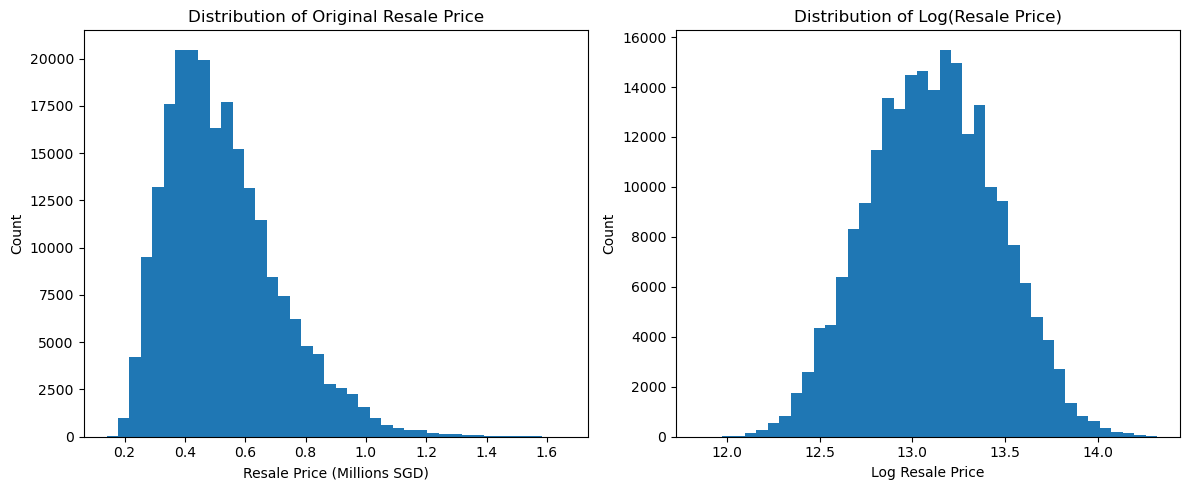

In [462]:
# Distribution and descriptive statistics for the target variable

def eda_target(df: pd.DataFrame):
    print("\n=== EDA 1: Target Summary ===")
    
    # Generate descriptive statistics with selected percentiles
    desc = df[TARGET].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
    desc = desc.map(lambda x: f"{x:,.0f}")
    print(desc)
    
    # Measure skewness of the original target distribution
    original_skew = df[TARGET].skew()
    print("\nSkewness (original):", round(original_skew, 3))
    
    # Plot histograms for original and log-transformed resale price
    plt.figure(figsize=(12,5), dpi=100)

    plt.subplot(1,2,1)
    
    # Histogram of original resale price
    plt.hist(df["resale_price_mil"], bins=40)
    plt.title("Distribution of Original Resale Price")
    plt.xlabel("Resale Price (Millions SGD)")
    plt.ylabel("Count")

    # Apply log transformation to reduce skewness
    df["log_resale_price"] = np.log(df["resale_price"])
    
    # Measure skewness of the log-transformed target distribution
    log_skew = df["log_resale_price"].skew()
    print("Skewness (log):", round(log_skew, 3))
    print("")
    
    # Histogram of log-transformed resale price
    plt.subplot(1,2,2)
    plt.hist(df["log_resale_price"], bins=40)
    plt.title("Distribution of Log(Resale Price)")
    plt.xlabel("Log Resale Price")
    plt.ylabel("Count")
    
    plt.tight_layout()
    plt.show()
    
eda_target(df)

In [410]:
# Observation: 

# The original resale price distribution is moderately right-skewed, while the log-transformed distribution is much more symmetric, indicating that log transformation may be appropriate for modeling.

## EDA 2: Structural Features vs Price


=== EDA 2: Structural Features vs Price ===


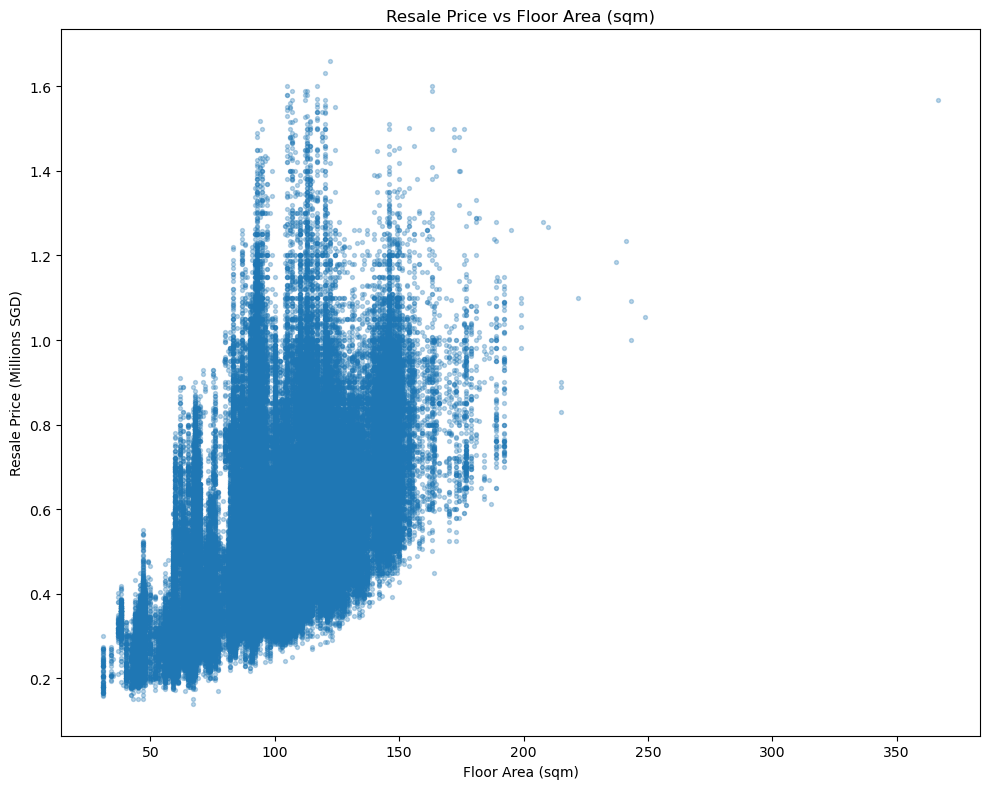

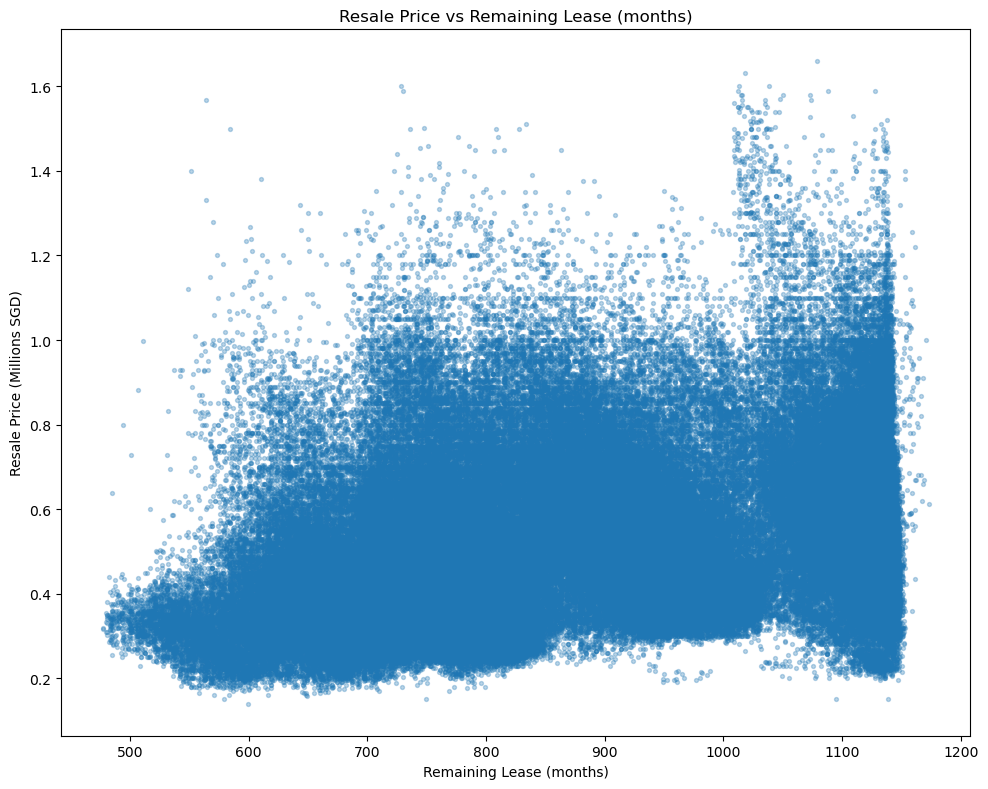

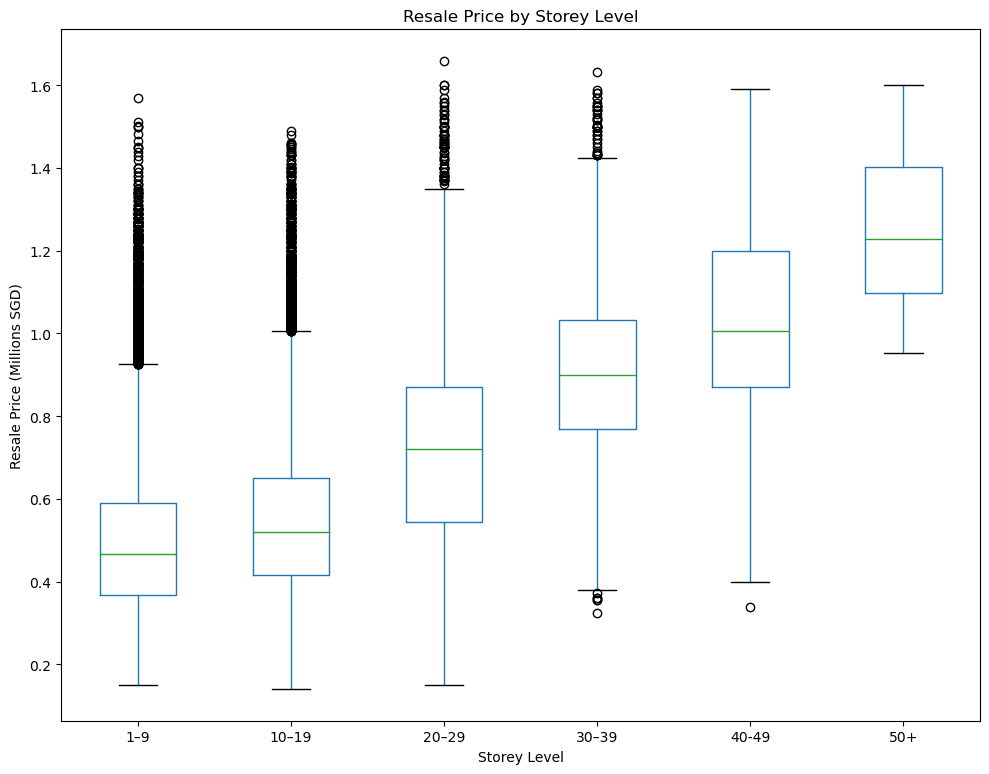

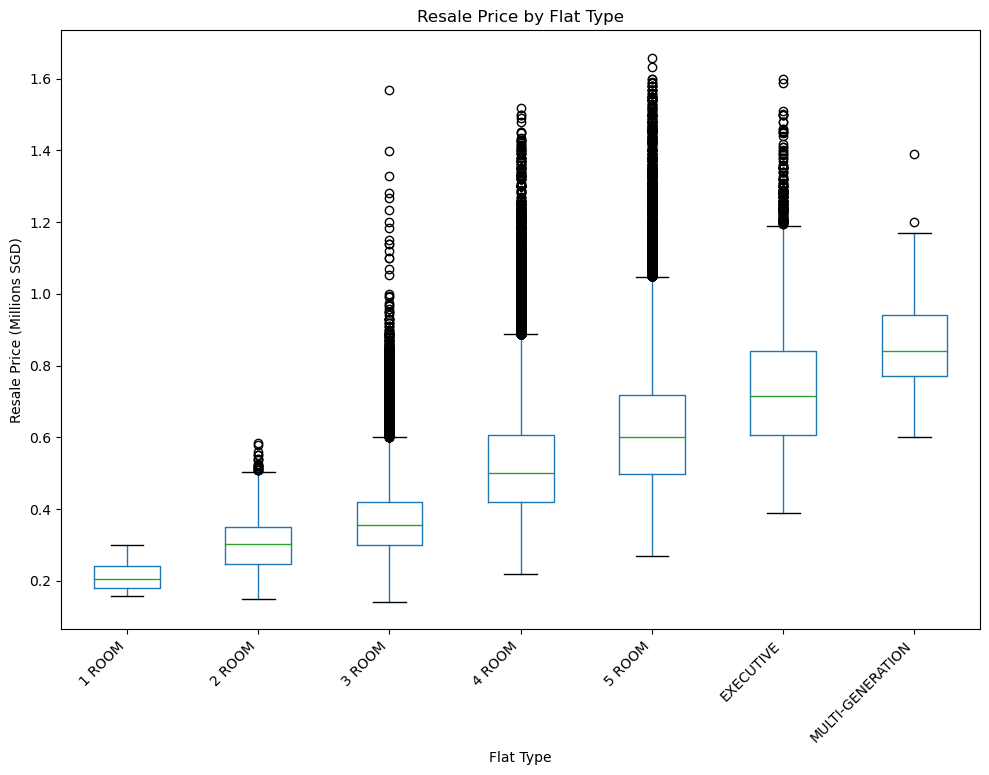

In [411]:
# Scatter plots for numeric structural features
# Box plots for grouped structural comparisons

def eda_structural(df: pd.DataFrame):
    print("\n=== EDA 2: Structural Features vs Price ===")

    # Loop through structural variables
    for col in NUM_STRUCT_COLS:
        label = LABEL_MAP.get(col, col)

        # Group comparison using box plot: storey level vs resale price
        if col == "storey_mid":
            fig, ax = plt.subplots(figsize=(10,8), dpi=100)
            bins = [0, 9, 19, 29, 39, 49, 60]
            labels = ["1–9", "10–19", "20–29", "30–39", "40-49", "50+"]

            tmp = df[["storey_mid", "resale_price_mil"]].copy()
            tmp["storey_band"] = pd.cut(tmp["storey_mid"], bins=bins, labels=labels, include_lowest=True)
            tmp.boxplot(column="resale_price_mil", by="storey_band", ax=ax, grid=False)
            ax.set_title("Resale Price by Storey Level")
            fig.suptitle("")
            ax.set_xlabel("Storey Level")
            ax.set_ylabel("Resale Price (Millions SGD)")
            plt.tight_layout()
            plt.show()

        # Scatter plot for continuous structural variables
        else:    
            plt.figure(figsize=(10,8), dpi=100)
            plt.scatter(df[col], df["resale_price_mil"], s=8, alpha=0.3)
            plt.title(f"Resale Price vs {label}")
            plt.xlabel(label)
            plt.ylabel("Resale Price (Millions SGD)")
            plt.tight_layout()
            plt.show()
            
    # Group comparison using box plot: flat type vs resale price
    fig, ax = plt.subplots(figsize=(10,8), dpi=100)
    tmp = df[[FLAT_TYPE_COL, "resale_price_mil"]].copy()
    tmp.boxplot(column="resale_price_mil", by=FLAT_TYPE_COL, rot=45, ax=ax, grid=False)
    ax.set_title("Resale Price by Flat Type")
    fig.suptitle("")
    ax.set_xlabel("Flat Type")
    ax.set_ylabel("Resale Price (Millions SGD)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
    
eda_structural(df)

In [412]:
# Observations:

# Floor Area: Resale price generally increases with floor area, indicating that larger flats tend to command higher prices.

# Remaining Lease: Flats with longer remaining lease generally tend to have higher resale prices, although the relationship appears more dispersed than floor area.

# Storey Level: Median resale price increases with storey level, suggesting that higher-floor units tend to be priced at a premium.

# Flat Type: Median resale price rises consistently from smaller to larger flat types, indicating that bigger flat categories generally command higher prices.

## EDA 3: Spatial Accessibility vs Price


=== EDA 3: Spatial Accessibility vs Price ===


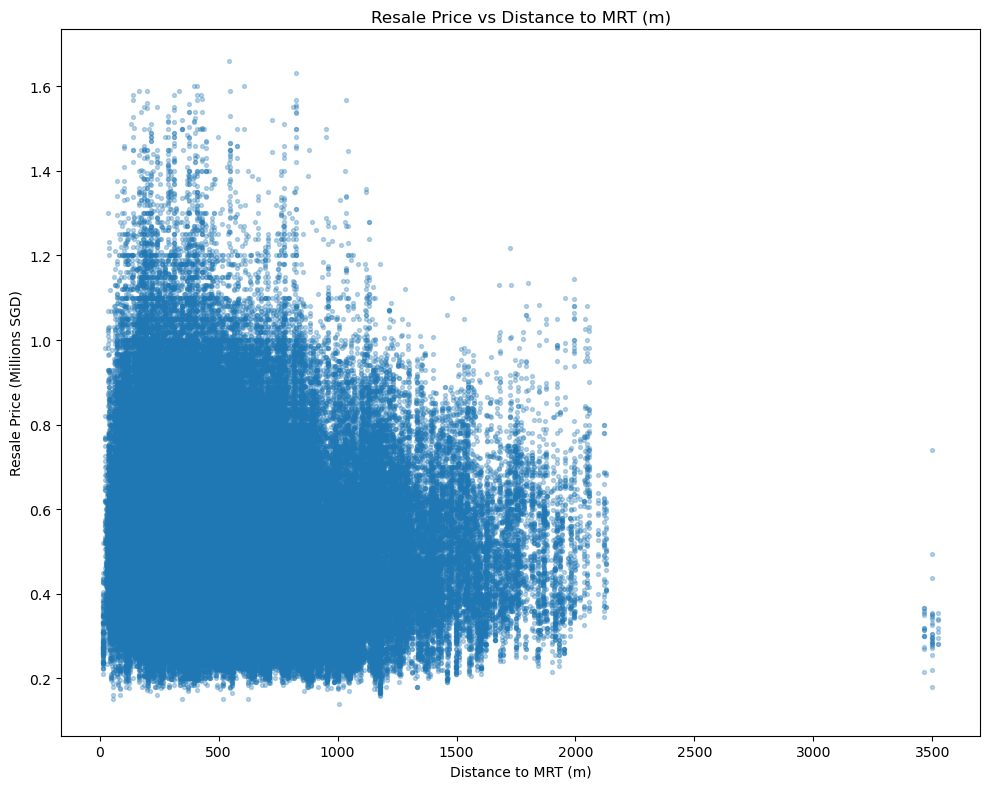

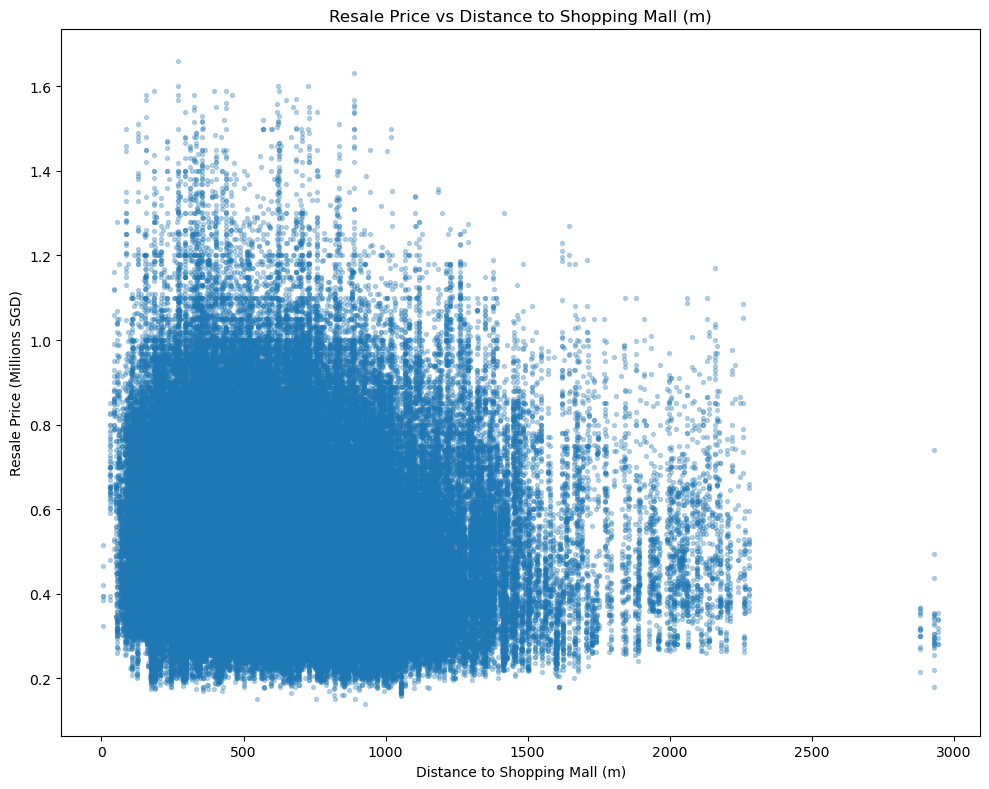

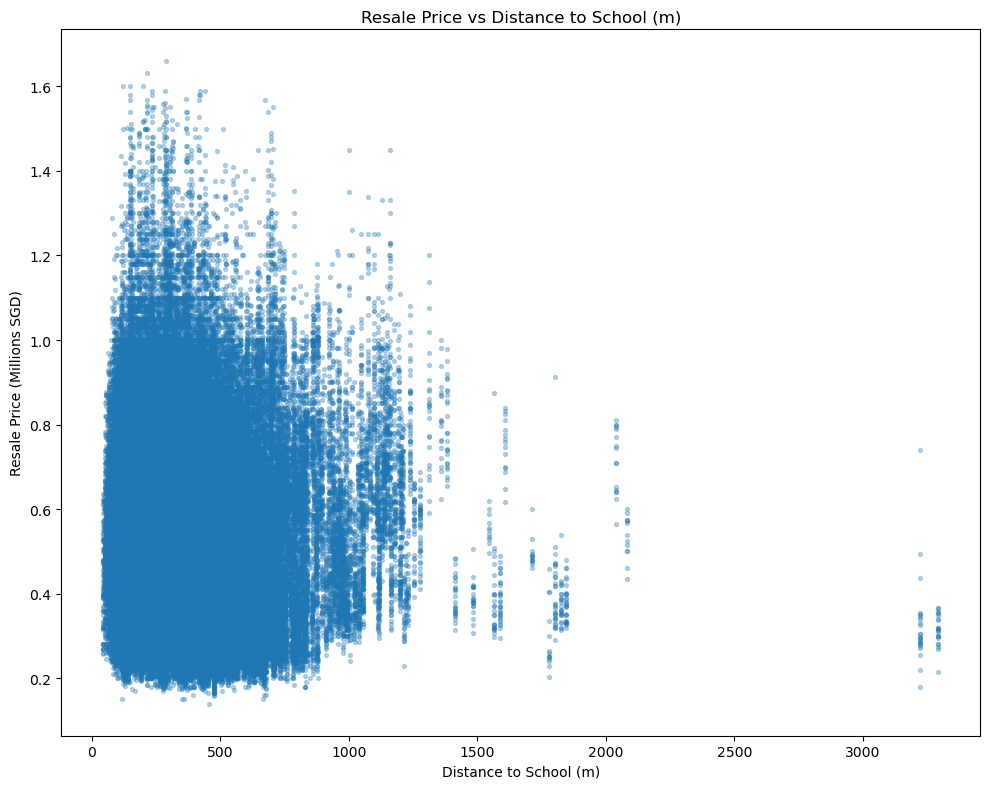

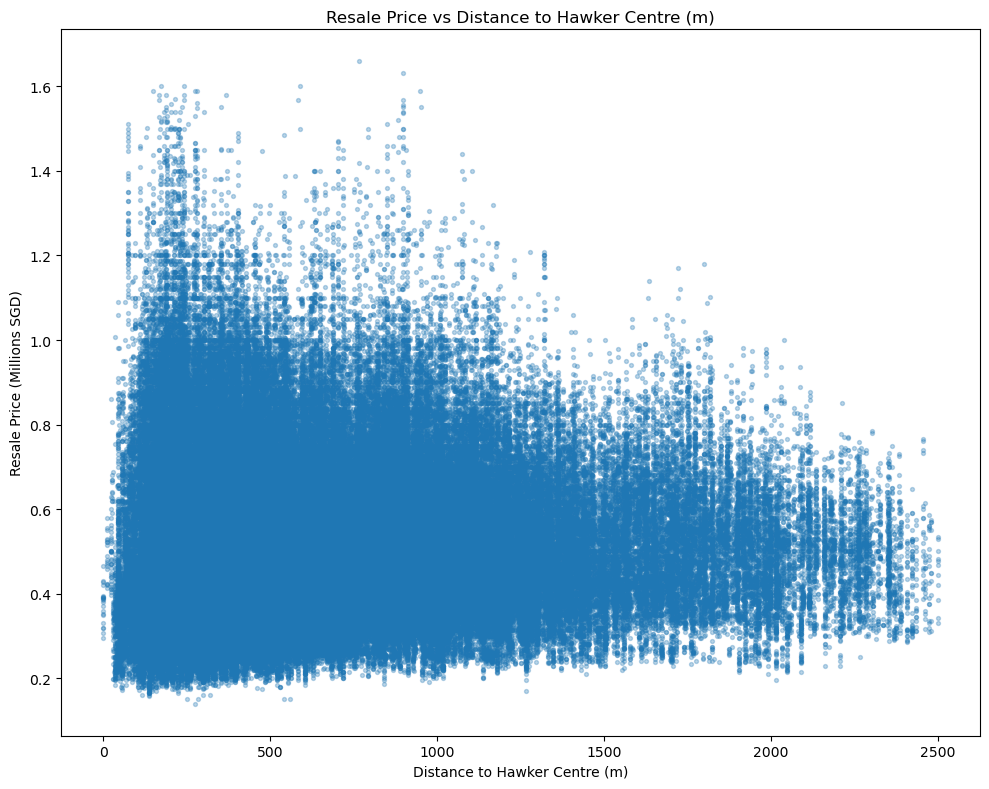

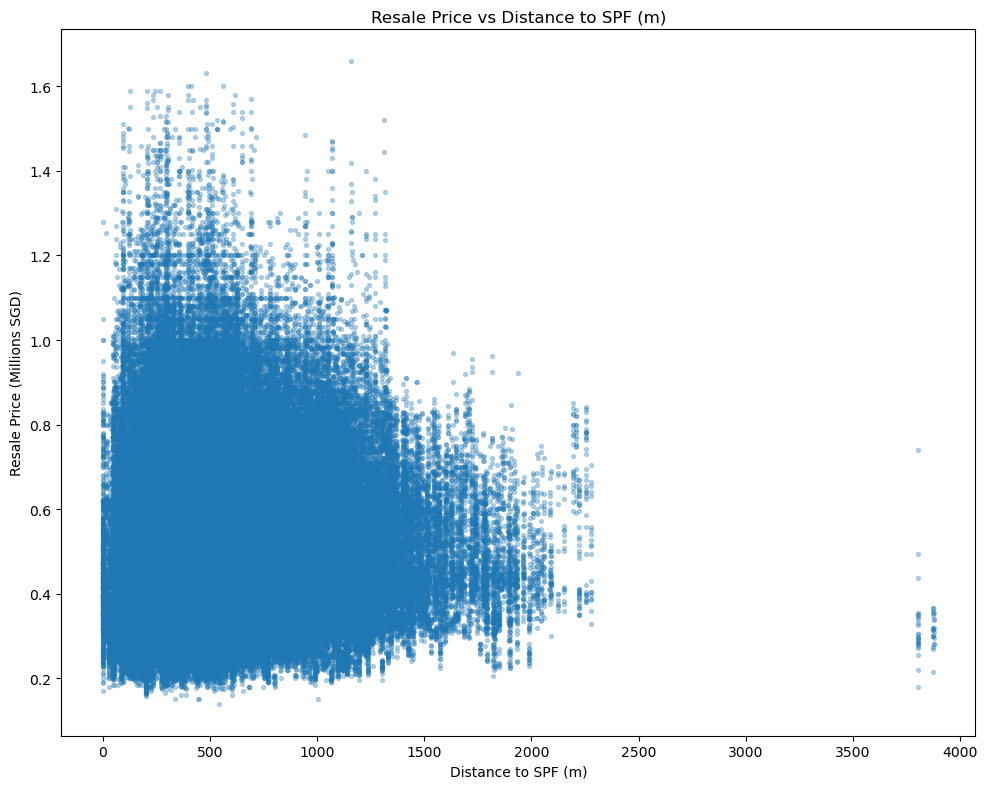

In [413]:
# Scatter plots for distance-based accessibility features

def eda_spatial(df: pd.DataFrame):
    print("\n=== EDA 3: Spatial Accessibility vs Price ===")

    # Loop through each distance feature
    for col in DIST_COLS:
        label = LABEL_MAP.get(col, col)

        # Scatter plot: distance feature vs resale price
        plt.figure(figsize=(10,8), dpi=100)
        plt.scatter(df[col], df["resale_price_mil"], s=8, alpha=0.3)
        plt.title(f"Resale Price vs {label}")
        plt.xlabel(label)
        plt.ylabel("Resale Price (Millions SGD)")
        plt.tight_layout()
        plt.show()

eda_spatial(df)

In [414]:
# Observations:

# Distance to MRT: The scatter suggests a negative association between MRT distance and resale price, with higher prices more commonly observed among flats located nearer to MRT stations. However, substantial dispersion remains across the distribution.
# Distance to Mall: The scatter suggests a weaker negative association between mall distance and resale price, although the relationship is less distinct than for MRT distance.
# Distance to School: The scatter shows a weak and unclear relationship between school distance and resale price, suggesting limited standalone explanatory value.
# Distance to Hawker Centre: The scatter indicates a weak and noisy relationship between hawker centre distance and resale price, with no strong visible pattern.
# Distance to SPF: The scatter shows a weak and unclear relationship between SPF distance and resale price, suggesting limited direct association with resale price.

## EDA 4: Town-level Variation


=== EDA 4: Town-level Variation ===
                 count  mean  median
town                                
ANG MO KIO        9127  0.48    0.42
YISHUN           15292  0.45    0.43
BEDOK            11681  0.48    0.43
JURONG EAST       4559  0.47    0.44
WOODLANDS        15937  0.48    0.46
GEYLANG           5558  0.51    0.46
JURONG WEST      14789  0.46    0.46
BUKIT BATOK       9345  0.50    0.47
BUKIT PANJANG     8016  0.50    0.48
CHOA CHU KANG    10133  0.49    0.49
CLEMENTI          4990  0.56    0.49
HOUGANG          11333  0.52    0.49
MARINE PARADE     1377  0.56    0.49
TOA PAYOH         7302  0.57    0.50
SEMBAWANG         6813  0.50    0.50
SENGKANG         18317  0.53    0.52
SERANGOON         3988  0.56    0.53
PUNGGOL          16296  0.54    0.53
TAMPINES         15336  0.56    0.54
CENTRAL AREA      1750  0.69    0.56
PASIR RIS         6468  0.58    0.57
KALLANG/WHAMPOA   6866  0.59    0.57
BUKIT MERAH       8553  0.64    0.65
QUEENSTOWN        6078  0.64    0.66
B

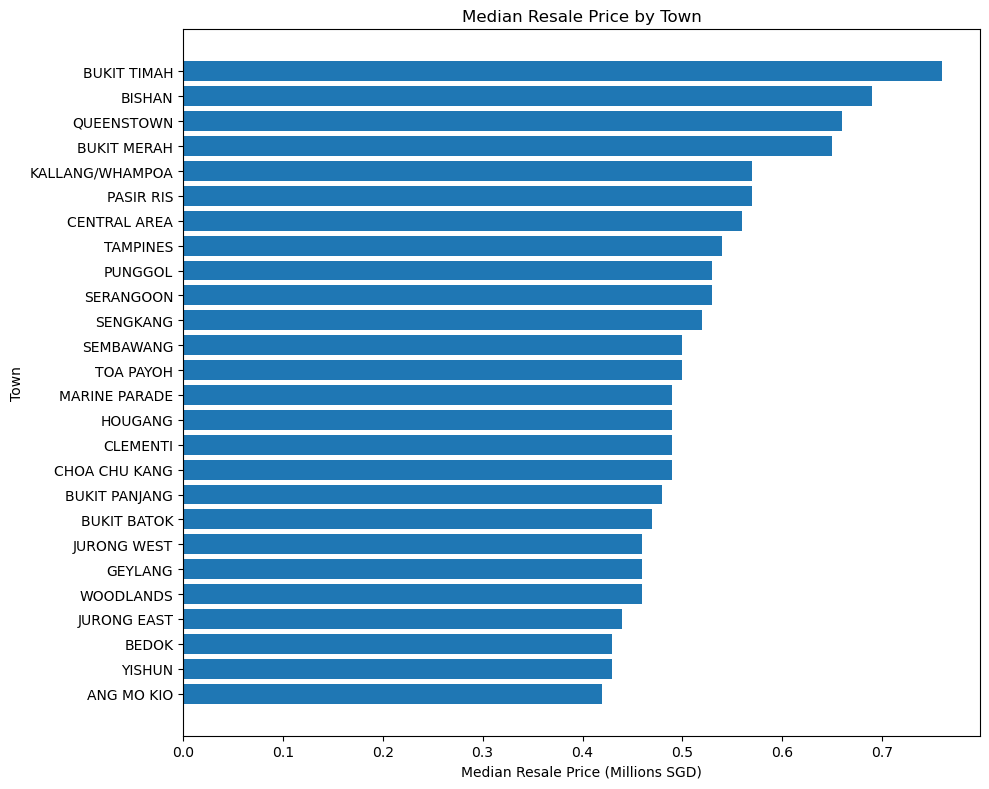

In [415]:
# Mean and median resale price by town

def eda_town(df: pd.DataFrame):
    print("\n=== EDA 4: Town-level Variation ===")

    # Keep only town and resale price columns
    tmp = df[[TOWN_COL, "resale_price_mil"]]

    # Summarise transaction count, mean price, and median price by town
    summary = (
        tmp.groupby(TOWN_COL)["resale_price_mil"]
        .agg(count="count", mean="mean", median="median")
        .round(2)
        .sort_values("median", ascending=True)
    )
    print(summary)

    # Horizontal bar plot of median resale price by town
    plt.figure(figsize=(10,8), dpi=100)
    plt.barh(summary.index, summary["median"].values)
    plt.title(f"Median Resale Price by Town")
    plt.xlabel("Median Resale Price (Millions SGD)")
    plt.ylabel("Town")
    plt.tight_layout()
    plt.show()
    
eda_town(df)

In [416]:
# Observation: 

# Town-level differences in median resale prices are substantial, suggesting that locational factors play an important role in explaining resale price variation beyond structural flat characteristics alone.

## EDA 5: Time Trend


=== EDA 5: Time Trend and Market Conditions ===


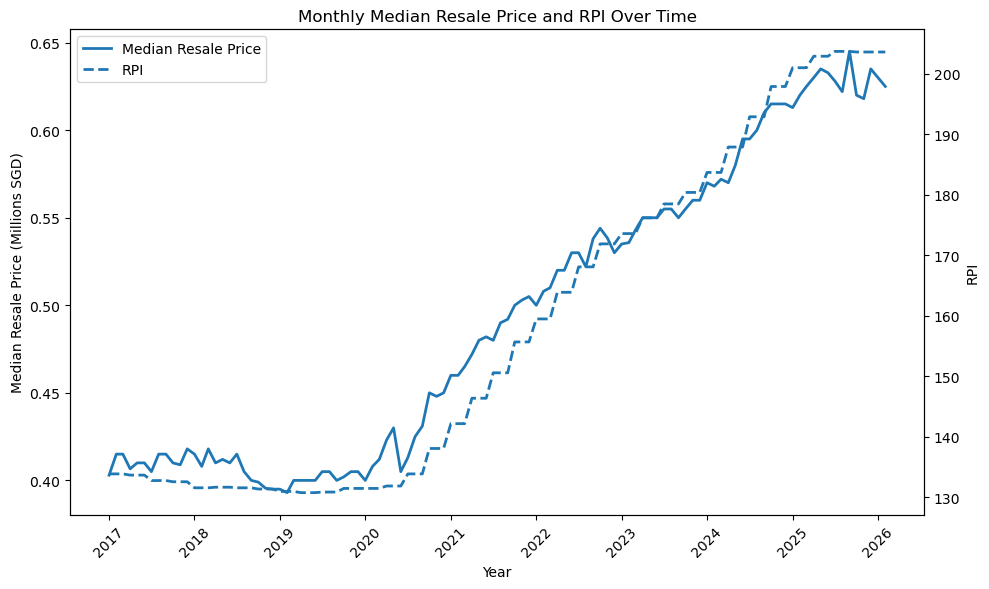

In [417]:
# Median resale price and RPI over time

def eda_time(df: pd.DataFrame):
    print("\n=== EDA 5: Time Trend and Market Conditions ===")

    # Keep only date, resale price, and RPI columns
    tmp = df[[DATE_COL, "resale_price_mil", "RPI"]]

    # Aggregate to monthly level
    monthly = (
        tmp.groupby(pd.Grouper(key=DATE_COL, freq="MS"))
           .agg(
               resale_price=("resale_price_mil", "median"),
               rpi=("RPI", "first")
           )
           .reset_index()
    )
    
    # Create dual-axis line chart
    fig, ax1 = plt.subplots(figsize=(10,6), dpi=100)

    # Median resale price on left axis
    line1, = ax1.plot(
        monthly[DATE_COL],
        monthly["resale_price"],
        label="Median Resale Price",
        linewidth=2
    )
    ax1.set_xlabel("Year")
    ax1.set_ylabel("Median Resale Price (Millions SGD)")
    ax1.tick_params(axis="x", rotation=45)

    # RPI on right axis
    ax2 = ax1.twinx()
    line2, = ax2.plot(
        monthly[DATE_COL],
        monthly["rpi"],
        linestyle="--",
        linewidth=2,
        label="RPI"
    )
    ax2.set_ylabel("RPI")

    # Combine legends from both axes
    lines = [line1, line2]
    labels = [line.get_label() for line in lines]
    ax1.legend(lines, labels, loc="upper left")
    plt.title("Monthly Median Resale Price and RPI Over Time")
    fig.tight_layout()
    plt.show()
    
eda_time(df)

In [418]:
# Observation:

# Both median resale prices and RPI show a clear upward trend over time, suggesting that broader market conditions likely contributed to the rise in resale prices.

## EDA 6: Correlation Analysis


=== EDA 6: Correlation Matrix ===


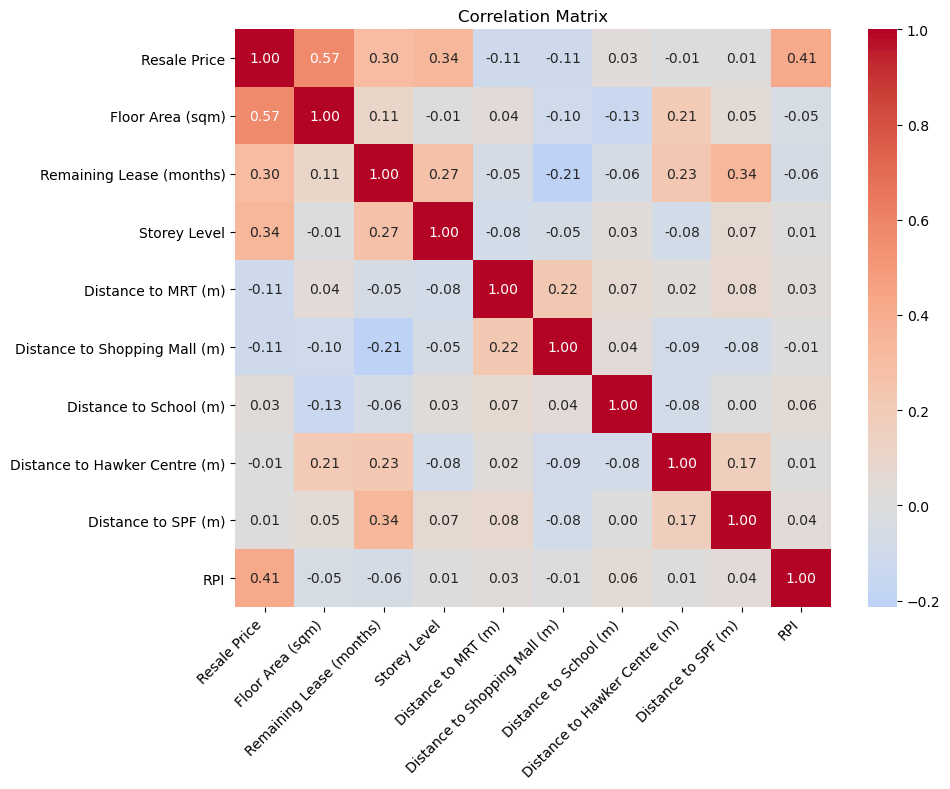

In [419]:
# Correlation matrix for numeric predictors and the target variable

def eda_correlation(df: pd.DataFrame):
    print("\n=== EDA 6: Correlation Matrix ===")

    # Select target, structural, distance, and market condition (RPI) variables
    cols = [TARGET] + NUM_STRUCT_COLS + DIST_COLS + ["RPI"]
    cols = [c for c in cols if c in df.columns]

    # Compute correlation matrix
    corr = df[cols].corr()
    
    # Use readable labels for the heatmap axes
    display_labels = [LABEL_MAP.get(c, c) for c in cols]

    plt.figure(figsize=(10,8), dpi=100)

    
    # Plot heatmap of pairwise correlations
    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        xticklabels=display_labels,
        yticklabels=display_labels
    )
    plt.xticks(rotation=45, ha="right")
    plt.title("Correlation Matrix")
    plt.tight_layout()
    plt.show()
    
eda_correlation(df)

In [420]:
# Observation:

# Structural features such as floor area, remaining lease, and storey level show stronger positive correlations with resale price than the distance variables, suggesting that structural characteristics may have a stronger linear relationship with resale price.

## EDA 7: Multicollinearity Assessment


=== EDA 7: Multicollinearity Assessment (VIF) ===
                  feature    VIF
2  remaining_lease_months  1.340
8           dist_to_spf_m  1.162
7        dist_to_hawker_m  1.135
3              storey_mid  1.113
5          dist_to_mall_m  1.109
4           dist_to_mrt_m  1.078
1          floor_area_sqm  1.077
6        dist_to_school_m  1.032
9                     RPI  1.014


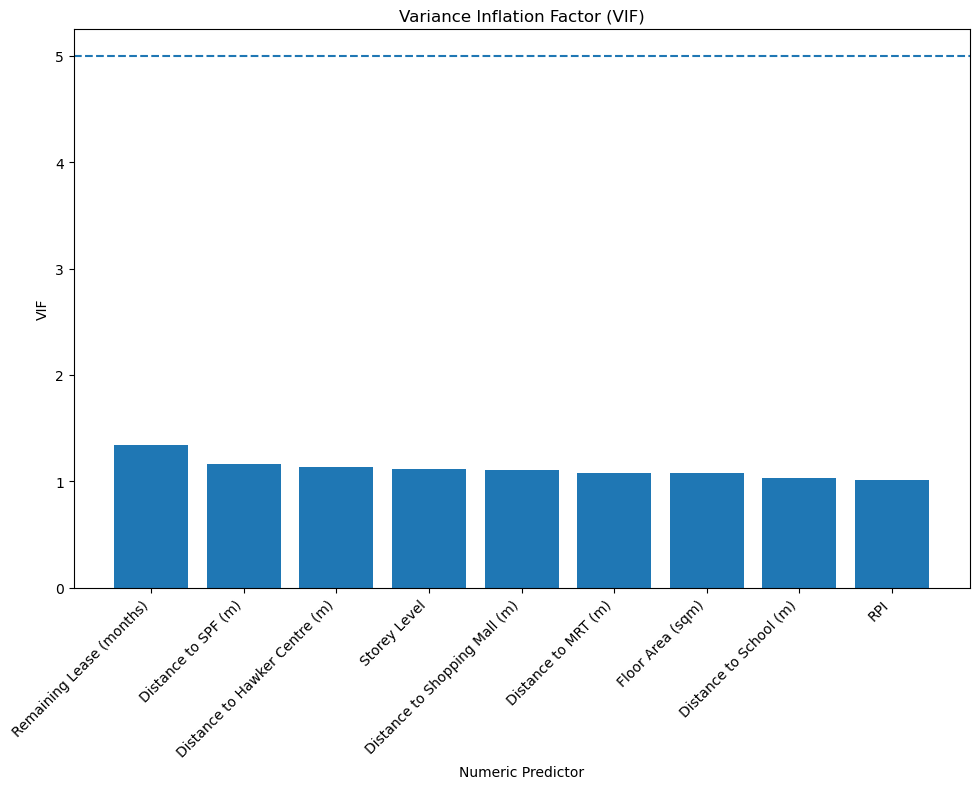

In [421]:
# Variance Inflation Factor (VIF) for numeric predictors

def eda_vif(df: pd.DataFrame):
    print("\n=== EDA 7: Multicollinearity Assessment (VIF) ===")

    # Select numeric predictors for VIF calculation
    vif_cols = NUM_STRUCT_COLS + DIST_COLS + ["RPI"]
    vif_cols = [c for c in vif_cols if c in df.columns]

    # Add constant term required for VIF calculation
    X = df[vif_cols].copy()
    X = add_constant(X)

    # Compute VIF for each column
    vif_data = pd.DataFrame({
        "feature": X.columns,
        "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    })

    # Round VIF values for easier reading
    vif_data["VIF"] = vif_data["VIF"].round(3)
    
    # Exclude constant and sort by highest VIF
    vif_data = vif_data[vif_data["feature"] != "const"].sort_values("VIF", ascending=False)
    print(vif_data)

    # Create readable labels for plotting
    vif_plot = vif_data.copy()
    vif_plot["label"] = vif_plot["feature"].map(lambda x: LABEL_MAP.get(x, x))
    
    plt.figure(figsize=(10, 8), dpi=100)
    plt.bar(vif_plot["label"], vif_plot["VIF"])
    plt.axhline(5, linestyle="--", label="VIF = 5")
    plt.title("Variance Inflation Factor (VIF)")
    plt.xlabel("Numeric Predictor")
    plt.ylabel("VIF")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
    
eda_vif(df)

In [422]:
# Observation:

# All predictors have VIF values close to 1 and well below common thresholds, suggesting that multicollinearity is not a concern among the selected numeric predictors.

In [423]:
# Feature columns to be used for modeling

keep_cols = [
    "date",
    "floor_area_sqm",
    "storey_mid",
    "remaining_lease_months",
    "town",
    "flat_type",
    "flat_model",
    "dist_to_mrt_m",
    "dist_to_mall_m",
    "dist_to_school_m",
    "dist_to_hawker_m",
    "dist_to_spf_m",
    "RPI",
    "resale_price"
]

In [424]:
# Make a new copy of df with just the columns from keep_cols
df = df[keep_cols].copy()

## Modelling

In [425]:
# Define target variable
target = "resale_price"

# Define predictor columns used for modelling
feature_cols = [
    "floor_area_sqm", 
    "storey_mid", 
    "flat_type",
    "remaining_lease_months",
    "town", 
    "flat_model",
    "dist_to_mrt_m",
    "dist_to_mall_m",
    "dist_to_school_m",
    "dist_to_hawker_m",
    "dist_to_spf_m",
    "RPI"
]

# Keep only date, predictors, and target
data = df[["date"] + feature_cols + [target]].copy()

# Time-based train-test split cutoff
cutoff = pd.Timestamp("2024-12-31")

# Training set: transactions up to end-2024
train = data[data["date"] <= cutoff]

# Test set: transactions after end-2024
test  = data[data["date"] > cutoff]

# Separate predictors and target for training
X_train = train[feature_cols]
y_train = train[target]

# Separate predictors and target for testing
X_test  = test[feature_cols]
y_test  = test[target]

# Numeric features passed through without encoding
num_features = [
    "floor_area_sqm", 
    "storey_mid", 
    "remaining_lease_months",
    "dist_to_mrt_m",
    "dist_to_mall_m",
    "dist_to_school_m",
    "dist_to_hawker_m",
    "dist_to_spf_m",
    "RPI"
]

# Categorical features to be one-hot encoded
cat_features = ["town", "flat_type", "flat_model"]

# Preprocessing pipeline: keep numeric features as it is and one-hot encode categorical features
preprocess = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
    ],
    remainder="drop"
)

## Cross-Validation

In [426]:
# Create a function to run time-series cross-validation for a given model
def run_timeseries_cv(model, preprocess, X_train, y_train, n_splits=5, n_jobs=-1, log_y=False):
    
     # Wrap model so that fitting is done on log(y) and predictions are transformed back to the original target scale
    if log_y:
        model = TransformedTargetRegressor(regressor=model, func=np.log, inverse_func=np.exp)

    # Build full pipeline with preprocessing and model
    pipe = Pipeline([
        ("prep", preprocess),
        ("model", model)
    ])

    # Time-series split to preserve temporal order
    tscv = TimeSeriesSplit(n_splits=n_splits)

    # Evaluation metrics for cross-validation
    scoring = {
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error",
        "r2": "r2"
    }

    # Perform cross-validation
    cv = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=tscv,
        scoring=scoring,
        n_jobs=n_jobs
    )

    # Convert negative error scores back to positive values
    mae_scores = -cv["test_mae"]
    rmse_scores = -cv["test_rmse"]
    r2_scores = cv["test_r2"]

    # Create dataframe of fold-by-fold results
    cv_df = pd.DataFrame({
        "Fold": range(1, len(mae_scores)+1),
        "MAE": mae_scores,
        "RMSE": rmse_scores,
        "R2": r2_scores
    })

    # Add row of mean performance across folds
    mean_row = pd.DataFrame({
        "Fold": ["Mean"],
        "MAE": [mae_scores.mean()],
        "RMSE": [rmse_scores.mean()],
        "R2": [r2_scores.mean()]
    })

    # Append mean row to cv fold dataframe
    cv_df = pd.concat([cv_df, mean_row], ignore_index=True)

    # Round values for cleaner display
    cv_df = cv_df.round({"MAE":0, "RMSE":0, "R2":4})

    return cv_df

## Linear Regression

In [427]:
# Run time-series cross-validation for Linear Regression
lr_cv = run_timeseries_cv(LinearRegression(), preprocess, X_train, y_train)
lr_cv

,Fold,MAE,RMSE,R2
0,1,40805.0,53409.0,0.8802
1,2,43039.0,57230.0,0.8701
2,3,42684.0,56143.0,0.8860
3,4,44714.0,60049.0,0.8793
4,5,49669.0,67829.0,0.8678
5,Mean,44182.0,58932.0,0.8767


## Linear Regression - log(y) 

In [287]:
# Run time-series cross-validation for log-transformed Linear Regression
lr_log_cv = run_timeseries_cv(LinearRegression(), preprocess, X_train, y_train, log_y=True)
lr_log_cv

,Fold,MAE,RMSE,R2
0,1,34985.0,48215.0,0.9024
1,2,35172.0,48892.0,0.9052
2,3,37542.0,51039.0,0.9058
3,4,38086.0,51142.0,0.9124
4,5,42433.0,69511.0,0.8611
5,Mean,37644.0,53760.0,0.8974


In [ ]:
# The log-transformed model performed better overall than the non-log model. It achieved lower average MAE (37644) and RMSE (53760), together with a higher average R-squared (0.8974), indicating better predictive accuracy and model fit. 
# This suggests that log transformation made the target variable more suitable for modelling, likely by reducing right-skewness and the influence of extreme values.

## Random Forest Regressor

In [177]:
# Define Random Forest model
model_rf = RandomForestRegressor(n_estimators=10, random_state=42, n_jobs=-1)

# Run time-series cross-validation for Random Forest
rf_cv = run_timeseries_cv(model_rf, preprocess, X_train, y_train)
rf_cv

,Fold,MAE,RMSE,R2
0,1,28672.0,41778.0,0.9267
1,2,31380.0,44333.0,0.9220
2,3,50349.0,64693.0,0.8486
3,4,40103.0,55015.0,0.8987
4,5,43707.0,60744.0,0.8940
5,Mean,38842.0,53313.0,0.8980


## Random Forest Regressor - log(y)

In [178]:
# Run time-series cross-validation for log-transformed Random Forest
rf_log_cv = run_timeseries_cv(model_rf, preprocess, X_train, y_train, log_y=True)
rf_log_cv

,Fold,MAE,RMSE,R2
0,1,29001.0,42969.0,0.9225
1,2,32834.0,47335.0,0.9111
2,3,51696.0,66756.0,0.8388
3,4,41275.0,56764.0,0.8921
4,5,44497.0,61638.0,0.8908
5,Mean,39860.0,55092.0,0.8911


In [ ]:
# The non-log Random Forest model performed better overall than the log-transformed version. It achieved lower average MAE and RMSE, together with a higher average R-squared, indicating slightly better predictive accuracy and model fit. 
# This suggests that log transformation was not beneficial for Random Forest in this case.
# Overall Random Forest still performed better than Linear Regression.

## Random Forest Regressor (n_estimators=300)

In [52]:
# Define Random Forest model with 300 trees
model_rf_300 = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)

# Run time-series cross-validation for Random Forest
rf_300_cv = run_timeseries_cv(model_rf_300, preprocess, X_train, y_train)
rf_300_cv

,Fold,MAE,RMSE,R2
0,1,26892.0,38828.0,0.9367
1,2,30335.0,43082.0,0.9264
2,3,49398.0,63071.0,0.8561
3,4,38980.0,53513.0,0.9041
4,5,42586.0,59380.0,0.8987
5,Mean,37638.0,51575.0,0.9044


## Random Forest Regressor (n_estimators=300) - log(y)

In [46]:
# Run time-series cross-validation for log-transformed Random Forest
rf_300_log_cv = run_timeseries_cv(model_rf_300, preprocess, X_train, y_train, log_y=True)
rf_300_log_cv

,Fold,MAE,RMSE,R2
0,1,27215.0,40116.0,0.9324
1,2,31356.0,45280.0,0.9187
2,3,51145.0,65546.0,0.8446
3,4,40337.0,55348.0,0.8974
4,5,43630.0,60654.0,0.8943
5,Mean,38737.0,53389.0,0.8975


In [ ]:
# For the 300-tree Random Forest models, the non-log version still performed better overall than the log-transformed version. It achieved lower average MAE (37638) and RMSE (51575), together with a higher average R-squared (0.9044), indicating slightly better predictive accuracy and model fit.
# Compared with the 10-tree models, both 300-tree models improved overall performance, suggesting that increasing the number of trees helped the model generalise better and produce more stable predictions. 
# Among all the Random Forest results, the 300-tree non-log model performed best overall.

## Final Model Linear Regression

In [444]:
# Define final Linear Regression model
final_model_lr = LinearRegression()

# Build final pipeline with preprocessing and model
final_pipe_lr = Pipeline(steps=[
    ("prep", preprocess),
    ("model", final_model_lr)
])

# Fit model on full training data
final_pipe_lr.fit(X_train, y_train)

# Generate predictions on the test set
pred_lr = final_pipe_lr.predict(X_test)

# Compute test set evaluation metrics
mae_lr  = mean_absolute_error(y_test, pred_lr)
rmse_lr = mean_squared_error(y_test, pred_lr, squared=False)
r2_lr   = r2_score(y_test, pred_lr)

print(f"Test MAE:  {mae_lr:,.0f}")
print(f"Test RMSE: {rmse_lr:,.0f}")
print(f"Test R2:   {r2_lr:.4f}")

Test MAE:  54,423
Test RMSE: 75,860
Test R2:   0.8618


## Final Model Linear Regression - log(y)

In [446]:
# Define log-transformed Linear Regression model
final_model_log_lr = TransformedTargetRegressor(
    regressor=LinearRegression(),
    func=np.log,
    inverse_func=np.exp
)

# Build final pipeline with preprocessing and model
final_pipe_log_lr = Pipeline(steps=[
    ("prep", preprocess),
    ("model", final_model_log_lr)
])

# Fit model on full training data
final_pipe_log_lr.fit(X_train, y_train)

# Generate predictions on the test set
pred_log_lr = final_pipe_log_lr.predict(X_test)

# Compute test set evaluation metrics
mae_log_lr  = mean_absolute_error(y_test, pred_log_lr)
rmse_log_lr = mean_squared_error(y_test, pred_log_lr, squared=False)
r2_log_lr   = r2_score(y_test, pred_log_lr)

print(f"Log-LR Test MAE:  {mae_log_lr:,.0f}")
print(f"Log-LR Test RMSE: {rmse_log_lr:,.0f}")
print(f"Log-LR Test R2:   {r2_log_lr:.4f}")

Log-LR Test MAE:  44,989
Log-LR Test RMSE: 60,149
Log-LR Test R2:   0.9131


## Final Model Random Forest Regressor (n_estimators=300)

In [428]:
# Define final Random Forest model
final_model_rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

# Build final pipeline with preprocessing and model
final_pipe_rf = Pipeline(steps=[
    ("prep", preprocess),
    ("model", final_model_rf)
])

# Fit model on full training data
final_pipe_rf.fit(X_train, y_train)

# Generate predictions on the test set
pred_rf = final_pipe_rf.predict(X_test)

# Compute test set evaluation metrics
mae_rf  = mean_absolute_error(y_test, pred_rf)
rmse_rf = mean_squared_error(y_test, pred_rf, squared=False)
r2_rf   = r2_score(y_test, pred_rf)


print(f"RF Test MAE:  {mae_rf:,.0f}")
print(f"RF Test RMSE: {rmse_rf:,.0f}")
print(f"RF Test R2:   {r2_rf:.4f}")

RF Test MAE:  34,114
RF Test RMSE: 49,791
RF Test R2:   0.9405


## Final Model Random Forest Regressor (n_estimators=300) - log(y)

In [84]:
# Define log-transformed Random Forest model
final_model_log_rf = TransformedTargetRegressor(
    regressor=RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),
    func=np.log,
    inverse_func=np.exp
)

# Build final pipeline with preprocessing and model
final_pipe_log_rf = Pipeline(steps=[
    ("prep", preprocess),
    ("model", final_model_log_rf)
])

# Fit model on full training data
final_pipe_log_rf.fit(X_train, y_train)

# Generate predictions on the test set
pred_log_rf = final_pipe_log_rf.predict(X_test)

# Compute test set evaluation metrics
mae_log_rf  = mean_absolute_error(y_test, pred_log_rf)
rmse_log_rf = mean_squared_error(y_test, pred_log_rf, squared=False)
r2_log_rf   = r2_score(y_test, pred_log_rf)

print(f"Log-RF Test MAE:  {mae_log_rf:,.0f}")
print(f"Log-RF Test RMSE: {rmse_log_rf:,.0f}")
print(f"Log-RF Test R2:   {r2_log_rf:.4f}")

Log-RF Test MAE:  35,165
Log-RF Test RMSE: 51,822
Log-RF Test R2:   0.9355


## Final Models Test Result

In [89]:
# Compare final test set performance across all models
final_test_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Log Linear Regression",
        "Random Forest",
        "Log Random Forest"
    ],
    "MAE": [mae_lr, mae_log_lr, mae_rf, mae_log_rf],
    "RMSE": [rmse_lr, rmse_log_lr, rmse_rf, rmse_log_rf],
    "R2": [r2_lr, r2_log_lr, r2_rf, r2_log_rf]
}).round({"MAE": 0, "RMSE": 0, "R2": 4})

final_test_df

,Model,MAE,RMSE,R2
0,Linear Regression,54428.0,75857.0,0.8618
1,Log Linear Regression,44952.0,60124.0,0.9132
2,Random Forest,34114.0,49791.0,0.9405
3,Log Random Forest,35165.0,51822.0,0.9355


In [ ]:
# On the final hold-out test set, Random Forest performed best overall, with the non-log Random Forest achieving the lowest MAE (34114) and RMSE (49791), and the highest R-squared (0.9405). This indicates the strongest predictive accuracy and model fit on unseen data.
# The log transformation clearly improved Linear Regression, but did not improve Random Forest. 
# Overall, this suggests that Random Forest was the better performing model, while log transformation was mainly beneficial for Linear Regression.

## Feature Importances

In [441]:
# Extract the fitted Random Forest model and transformed feature names
rf = final_pipe_rf.named_steps["model"]
feature_names = final_pipe_rf.named_steps["prep"].get_feature_names_out()

# Create and sort feature importances in descending order
imp = pd.Series(
    rf.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

# Keep the top 5 most important features
top5_df = imp.head(5).reset_index()
top5_df.columns = ["Feature", "Importance"]

# Clean feature name prefixes added during preprocessing
top5_df["Feature"] = top5_df["Feature"].str.replace("num__", "", regex=False)
top5_df["Feature"] = top5_df["Feature"].str.replace("cat__", "", regex=False)

# Format importance values for display
top5_df["Importance"] = top5_df["Importance"].round(3)
top5_df["Importance_pct"] = (top5_df["Importance"] * 100).round(2)

top5_df

,Feature,Importance,Importance_pct
0,floor_area_sqm,0.399,39.9
1,RPI,0.148,14.8
2,storey_mid,0.090,9.0
3,remaining_lease_months,0.069,6.9
4,dist_to_mrt_m,0.027,2.7


In [ ]:
# Among the top five predictors, floor area is the most influential, contributing about 39.9% of total feature importance. 
# This is followed by the resale price index at 14.8%, then storey level and remaining lease months. 
# Distance to the nearest MRT station ranks fifth at 2.7%, suggesting that while accessibility matters, the model relies more strongly on structural and market-related features when predicting resale price.